# Chapter 8 | Unsupervised Learning

    "if intelligence was a cake, unsupervised learning would be the
    cake, supervised learning would be the icing on the cake, and reinforcement
    learning would be the cherry on the cake"
Yann LeCun (Turing Award winner and Meta's Chief AI Scientists)

## Table of Contents
1. [Introduction](#1.-introduction)
2. [Clustering Algorithms](#2-clustering-algorithms)

## 1. Introduction
The main problem with Supervised Learning is that the vast majority of the available data is unlabeled (i.e., we have $X$ but we don't have $y$); here is where **Unsupervised Learning** becomes handy. 

In last chapter (Chapter 7), you already went through the most common Unsupervised Learning task: Dimensionality Reduction. Let's now introduce some others:

## 2. Clustering Algorithms
**Clustering** is the task of identifying similar instances and assigning them to **clusters** (i.e., groups of similar instances). It may sound similar to Classification, but here we don't have any label, so the algorithm needs to figure out on its own how to group instances.

Below an example of the Iris dataset having labels (on left) and not having them (on right). Even without having labels, it's easy to spot the lower-left cluster (the other 2 clusters are not that easy to spot, but we should consider that the Iris dataset has 2 other features not shown here, which allow Clustering algorithms to efficiently identify 3 clusters):

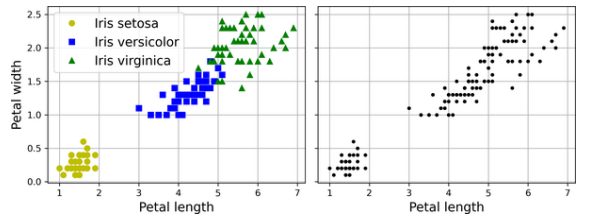

Clustering has a wide variety of applications:
- **Customer Segmentation** (useful for **Recommender Systems**);
- **Data Analysis** (so that we can analyze clusters separately);
- **Dimensionality Reduction** (we can measure each instance's **Affinity**, i.e., how well it fits, with each cluster; having $k$ clusters results in $k$ affinity-features, which may be used instead of the original features);
- **Feature Engineering** (**Affinity** can also be used as extra-feature);
- **Anomaly Detection** (low **Affinity** with all clusters likely identifies an anomaly);
- **Semi-Supervised Learning** (having few labels, we can propagate labels to all instances in same cluster, allowing for subsequent Supervised Learning);
- **Search Engines** (finding similar images to a reference one);
- **Image Segmentation** (clustering pixels according to their color, then replacing them with the mean of its cluster, reducing considerably the number of different colors).

We'll now look to 2 popular clustering algorithms:
- **k-means**;
- **DBSCAN**.

### k-means
**k-means** finds particular points which instances are centered around (this particular points are called **Centroids**) and then assign each instance to the closest Centroid. 

These Centroid are found in an iterative process in which they are first randomly initialized; then, a **Label** (or **Cluster ID**) is assigned to each instance (in the context of Clustering, the label is the index of the cluster to which the instance is assigned); then, centroids are updated, label are re-assigned and so on, until the algorithm converges (i.e., updating the centroids won't move them). The algorithms is guaranteed to converge, but it is not guaranteed to converge to global optimum (i.e., it may converge to a local optimum), based on the centroid initialization.

Let's for example generate 5 random blobs and plot them:

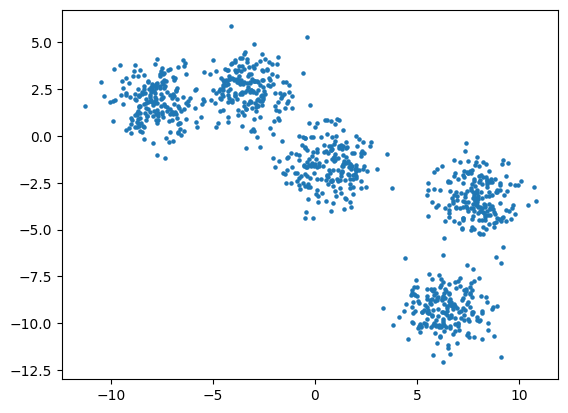

In [1]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

X, y = make_blobs(n_samples=1000, centers=5, cluster_std=1.1, random_state= 6)
plt.scatter(X[:, 0], X[:, 1], s = 5)

Note that y contains the correct **Cluster IDs** (we won't use this y, instead we want to predict it).

We can train a `KMeans` clusterer on this dataset:

In [2]:
from sklearn.cluster import KMeans
k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
y_pred = kmeans.fit_predict(X)

Note that we specified the number of clusters $k$ to be 5, which was obvious from the last image, but in general it is not that eays to find it (we will discuss about this later).

We can access the predicted Labels by variable `labels_`:

In [3]:
y_pred is kmeans.labels_

True

We can also access the Centroid's coordinates via the `cluster_centers_` variable:

In [4]:
kmeans.cluster_centers_

array([[-7.81783102,  1.82522458],
       [ 7.92822059, -3.29012278],
       [ 0.68414063, -1.57483574],
       [ 6.40762609, -9.23237439],
       [-3.24087048,  2.50748763]])

We can use the `predict()` method to assign new instances to the clusters:

In [5]:
import numpy as np

X_new = np.array([[0, 2], [3, 2], [0, -1]])
kmeans.predict(X_new)

array([4, 2, 2], dtype=int32)

We can also look at the **Clustering Decision Boundaries** by plotting the so called **Voronoi Tessellation**:

/tmp/ipykernel_826/2757163526.py:11: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', k)


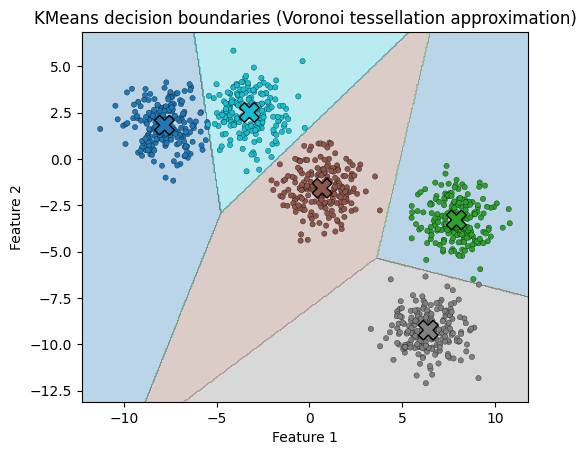

In [6]:
pad = 1.0
x_min, x_max = X[:, 0].min() - pad, X[:, 0].max() + pad
y_min, y_max = X[:, 1].min() - pad, X[:, 1].max() + pad
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 400),
                     np.linspace(y_min, y_max, 400))

grid_points = np.c_[xx.ravel(), yy.ravel()]
Z = kmeans.predict(grid_points)
Z = Z.reshape(xx.shape)

cmap = plt.cm.get_cmap('tab10', k)

plt.contourf(xx, yy, Z, alpha=0.3, cmap=cmap)

plt.scatter(X[:, 0], X[:, 1], c=kmeans.labels_, s=15, cmap=cmap, edgecolors='k', linewidth=0.2)

centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c=np.arange(k), cmap=cmap,
            marker='X', s=200, edgecolors='k', linewidth=1)

plt.title('KMeans decision boundaries (Voronoi tessellation approximation)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

The majority of instances were appropriately assigned, wile some may be mislabeled, especially near the boundaries.

Indeed, k-means doesnt behave well when blobs have different diameters, cause it only cares about the distance between the instance and the centroid.

What we did before is **Hard Clustering**, which means to assign a single cluster to each instance; another option is **Soft Clustering**, which means to assign to each instance a score per cluster.

With `KMeans`, we can get this score with the `transform()` method (in this case the score is simply the distance between the instance and each centroid):

In [7]:
kmeans.transform(X_new).round(2)

array([[ 7.82,  9.53,  3.64, 12.93,  3.28],
       [10.82,  7.23,  4.26, 11.74,  6.26],
       [ 8.31,  8.25,  0.89, 10.43,  4.78]])

These scores could be used as new dimensions, both for Dimensionality Reduction or for getting Extra Features.

#### Centroid Initialization Methods
As we said, the algorithm is guaranteed to converge to a local optimum, but not guaranteed to converge to the global optimum. This depends on the way we initialized the centroids.

It you happen to know where the centroids approximately fall (from another clustering algorithm for example), you can set the `init` hyperparameter to a NumPy array containing the list of centroids:

In [8]:
good_init = np.array([[-7, 2], [-3, 3], [1, -1], [6, -10], [7, -3]])
kmeans = KMeans(n_clusters=5, init=good_init, random_state=42)
kmeans.fit(X)

,n_clusters,5
,init,"array([[ -7, ... [ 7, -3]])"
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,42
,copy_x,True
,algorithm,'lloyd'


Another possibility is to run the algorithm multiple times by controlling the `n_init` hyperparameter (if we set the `init` parameter to `"random"`, the `n_init` is automatically set to `10`). The algorithm automatically stores the best solution when calling `fit()`, which is the one having the lowest **Inertia**:

$$inertia = \sum_i ||x^{(i)-c^{(i)}}||^2$$

If we mind, we can access a model's inertia by the `inertia_` variable (or the negative of this by calling `score(X)`):

In [9]:
kmeans.inertia_, kmeans.score(X)

(2217.552624157718, -2217.5526241577177)

In 2006, a new version of the algorithm was proposed, called **k-means++**: this introduced a smarter initialization step that tends to select centroids that are distant from one another, which allows the algorithm to converge more likely to the global optimum (think of it as spreading out fishing boats to increase chances of locating more fish).

The smart initialization works like this:
1. Choose one centroid $c^{(1)}$ uniformly at random from the dataset;
2. Take a new centroid $c^{(i)}$ choosing an instance $x^{(i)}$ with probability $D(x^{(i)})^2 / \sum_{j = 1}^m (x^{(j)})^2$, where $D(x^{(i)})$ is the distance between instance $x^{(i)}% and closest centroid (basically we are more likely to choose an instance which is farther away from already chosen centroids);
3. Repeat step 2 until $k$ centroids have been chosen.

By default, the `KMeans` class has `init = "k-means++"` (which automatically sets `n_init = 1`), which uses a variant of this algorithm called **Greedy k-means++** (instead of sampling a single centroid at each iteration, it samples multiple ones and picks the best).

In 2003, another variant was proposed: this tries to speed up the algorithm by avoiding many unnecessary distance calculation (however, this is not always true and depending on the sataset sometimes it even slows down training). Still, it may be useful with large datasets and many clusters. It can be implemented by setting `algorithm = "elkan"`.

In 2010, another variant was proposed: at each iteration, this version uses mini-batches, moving the centroids slightly (can speed up algorithm and most importantly allows to use it on datasets not fitting in memory). You can implement it with the class `MiniBatchKMeans`:

In [10]:
from sklearn.cluster import MiniBatchKMeans

minibatch_kmeans = MiniBatchKMeans(n_clusters=5, random_state=42)
minibatch_kmeans.fit(X)

,n_clusters,5
,init,'k-means++'
,max_iter,100
,batch_size,1024
,verbose,0
,compute_labels,True
,random_state,42
,tol,0.0
,max_no_improvement,10
,init_size,None
,n_init,'auto'


When the dataset doesn't fit in memory, you can use a **memmap** class (already introduced in Chapter 7), which is the best option. Otherwise, you could pass one mini-batch at a time and call `partial_fit()` (this requires multiple initialization and you are asked to select the best one).

#### Finding Optimal Number of Clusters
When choosing the optimal number of clusters, an idea is to use the Inertia as metric: higher number of clusters means instances will be much closer to its closest centroid, so the Inertia will be lower, meaning we can't just pick the lowest Inertia. However, by plotting the Inertia as a function of number of clusters $k$, we can spot an **Elbow** in which the Inertia starts decreasing slowly:


Text(0, 0.5, 'Inertia')

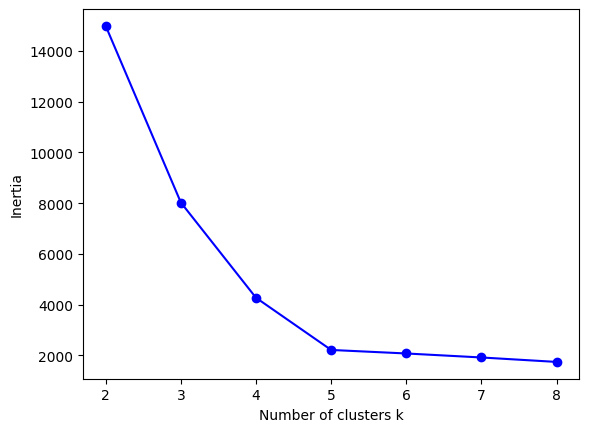

In [11]:
plt.plot(range(2, 9), [KMeans(n_clusters=k, random_state=42).fit(X).inertia_ for k in range(2, 9)], 'bo-')
plt.xlabel('Number of clusters k')
plt.ylabel('Inertia')

In the above example, we could think that 4 could be a good number of clusters (in reality, 5 was the correct answer).

A more precise, and computationally expensive, approach is to use the **Silhouette Score**, which is the mean **Silhouette Coefficient** over all instances. We can get the Silhouette Coefficient of the $i^{th}$ instance with the equation:

$$s^{(i)} = \frac{b^{(i)} - a^{(i)}}{max(a^{(i)}, b^{(i)})}$$
where:
- $a^{(i)}$ is the mean distance to the other instance in the **same** cluster;
- $b^{(i)}$ is the mean distance to the nearest-cluster (i.e., the mean distance to the instances of the closest cluster, defined as the one minimizing $b^{(i)}$ excluding the instance's own cluster).

This coefficient ranges between -1 and +1 where:
- -1 means the instance may have been assigned to wrong cluster;
- 0 means the instance is close to a cluster boundary;
- +1 means the instance is well inside its own cluster and far from others.

As we said, the Silhouette Score is the mean of this coefficient over all instances; in Sciki-Learn, we can compute it with the `silhouette_score()` function giving it the instances and the assigned labels:

In [12]:
from sklearn.metrics import silhouette_score

silhouette_score(X, kmeans.labels_)

0.6406435316578033

What we can do is to compare this score for different number of clusters:

Text(0, 0.5, 'Silhouette score')

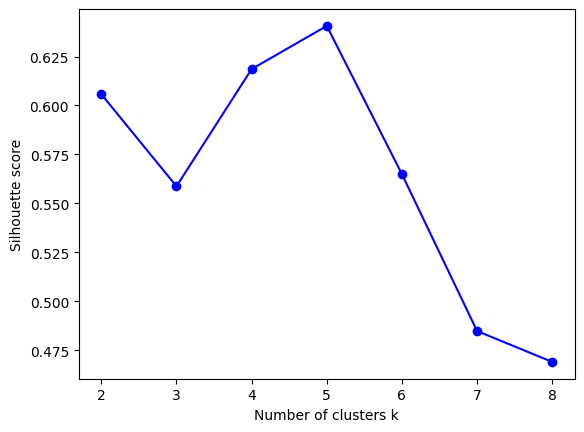

In [13]:
plt.plot(range(2, 9), [silhouette_score(X, KMeans(n_clusters=k, random_state=42).fit(X).labels_) for k in range(2, 9)], 'bo-')
plt.xlabel('Number of clusters k')
plt.ylabel('Silhouette score')

This highlights how $k=5$ is a very good choice.

Another strong visualization is the **Silhouette Diagram** obtained by plotting every instances's silhouette coefficient, sorted by the clusters they are assigned and by the value of the coefficient. Below an example of a Silhouette Diagram:

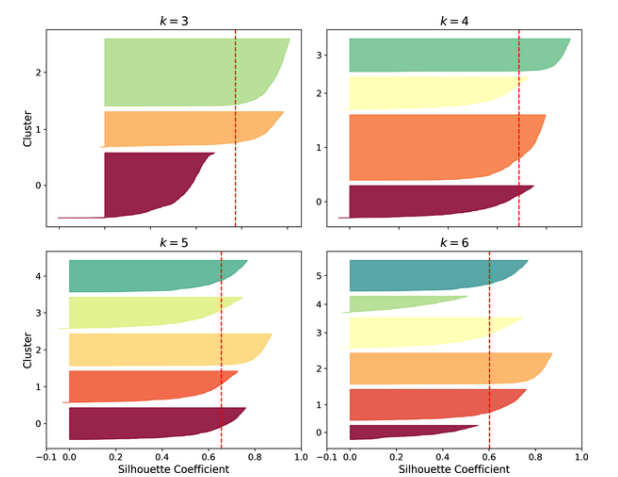

In each of the above plots, each knife shape represents a cluster: the height indicates the number of instances inside the cluster, while the width represents the sorted silhouette coefficient of the instances in the cluster (idea is that wider is better); the vertical dashed lines is the mean silhouette score for each number of clusters: when many instances have a lower coefficient than this score, then the cluster is rather bad (many instances are much too close to other clusters).

In the above example, with $k=3$ and $k=6$, we got rather bad clusters, while with $k=4$ and $k=5$ they are better. Even if these last 2 have similar silhouette diagrams, we could choose the one clustering where each cluster has a similar number of instances (here we may choose $k=5$ over $k=4$).

##### Limits of k-means
k-means is a fast and scalable algorithm; however, it has some downsides:
- needs to run several times to avoid suboptimal solutions;
- needs the number of clusters;
- doesn't behave well with clusters having different sizes, densities or non-sperhical shapes (below 2 examples of how k-means would cluster a dataset containing three ellipsoidal clusters).

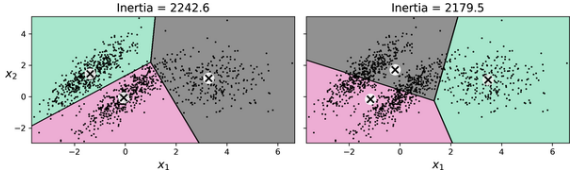

In the above, a **Gaussian Mixture Model** would perform well; generally, k-means can improve if we scale the features: this doesn't guarantee nice clusters, but it generally helps.


### DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
The **DBSCAN (Density-Based Spatial Clustering of Applications with Noise)** algorithm defines clusters as continuous regions of high density. It works like so:
- for each instance, it counts how many instances fall within a small distance $\epsilon$: this region is the $\epsilon$**-neighborhood**;
- if an instance as at least `min_samples` instances in its $\epsilon$-neighborhood, it is considered a **Core Instance** and all instances in the neighborhood belong to the same cluster (this may include other core instances: in that case they form a single cluster);
- an instance that is neither a core instance or inside a neighborhood is considered an **Anomaly**.

This works well if clusters are well-separated by low-density regions. 

Let's start by trying to implement it for the moons dataset:

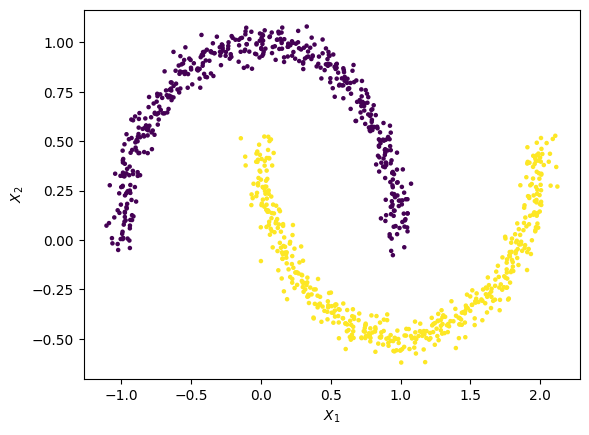

In [43]:
from sklearn.datasets import make_moons

X, y = make_moons(n_samples = 1000, noise = 0.05, random_state = 42)
plt.scatter(X[:, 0], X[:, 1], c = y, s = 5)
plt.xlabel('$X_1$')
plt.ylabel('$X_2$')
plt.show()

Let's trimplement it with the `DBSCAN` class:

In [ ]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps = 0.05, min_samples = 5)
dbscan.fit(X)

,eps,0.05
,min_samples,5
,metric,'euclidean'
,metric_params,None
,algorithm,'auto'
,leaf_size,30
,p,None
,n_jobs,None


We can then access the labels of each instance by accessing the `labels_` variable:

In [30]:
dbscan.labels_[:10]

array([ 0,  2, -1, -1,  1,  0,  0,  0,  2,  5])

Notice how some instances have a label of -1, which means they are considered Anomalies.

We can also access the indices of the core instances by `core_sampleindices_`, or access themselves by `components_`:

In [33]:
dbscan.core_sample_indices_[:10]

array([ 0,  4,  5,  6,  7,  8, 10, 11, 12, 13])

In [34]:
dbscan.components_

array([[-0.02137124,  0.40618608],
       [-0.84192557,  0.53058695],
       [ 0.58930337, -0.32137599],
       ...,
       [ 1.66258462, -0.3079193 ],
       [-0.94355873,  0.3278936 ],
       [ 0.79419406,  0.60777171]], shape=(808, 2))

If we would plot the above clustering, we would obtain this poor clustering:

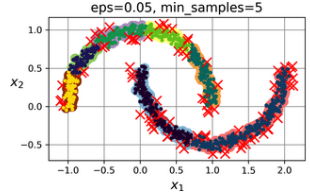

But it's enough to widen the instances' neighborhood by increasing `eps` to 0.2 to get this other clustering:

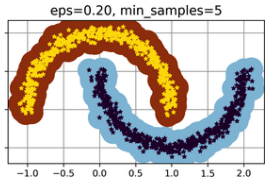

The `DBSCAN` class doesn't have a `predict()` method, but it has a `fit_predict()` one: this allows to use different classification algorithms based on the type of task. 

Let's for example implement a `KNeighborsClassifier` and use it for making predictions on new instances (we will both predict the cluster and estimated probability for each cluster):

In [47]:
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=50)
knn.fit(dbscan.components_, dbscan.labels_[dbscan.core_sample_indices_])

X_new = np.array([[-0.5, 0], [0, 0.5], [1, -0.1], [2, 1]])

knn.predict(X_new), knn.predict_proba(X_new)

(array([6, 0, 3, 2]),
 array([[0.24, 0.  , 0.  , 0.  , 0.  , 0.  , 0.76],
        [1.  , 0.  , 0.  , 0.  , 0.  , 0.  , 0.  ],
        [0.  , 0.  , 0.3 , 0.7 , 0.  , 0.  , 0.  ],
        [0.  , 0.  , 1.  , 0.  , 0.  , 0.  , 0.  ]]))

Above we chose to train just on the core instances (we could also choose to train on all instances, or on all instances but the anomalies).

If we plot the decision boundaries of this classifier we would obtain this:

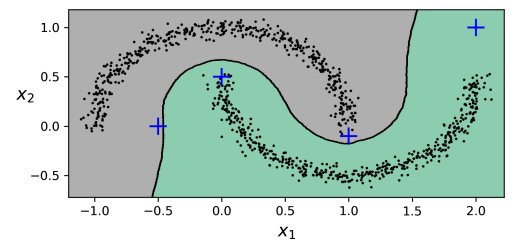

Not having anomalies, the classifier assigns a cluster even if an instances is far away from both clusters; let's introduce a Maximum Distance, so that the 2 instances that are far away from both clusters are classified as anomalies. This can be done using the `kneighbors()` method of the classifier which, given a set of instances, returns the distances and the indices of the $k$-nearest neighbors in the training set:

In [49]:
y_dist, y_pred_idx = knn.kneighbors(X_new, n_neighbors = 1)
y_pred = dbscan.labels_[dbscan.core_sample_indices_][y_pred_idx]
y_pred[y_dist > 0.2] = -1
y_pred.ravel()

array([-1,  0,  3, -1])

So, DBSCAN is a simple and powerful clustering algorithm: it is robust to outliers and it has only 2 parameters (`eps` and `min_samples`). 

However, it struggles if density varies across clusters or there's no sufficiently low-density region around clusters; its complexity is $O(m^2n)$, so it does not scale well to large datasets.

When density problems happen, you may want to try **Hierarchical DBSCAN (HDBSCAN)**, which can be implemented with `sklearn.cluster.HDBSCAN`.



### Other Algorithms
- **Agglomerative Clustering**: it builds a hierarchy of cluster from the bottom up; this gets clusters of various shapes and produce an informative cluster tree instead of forcing you to choose a particular cluster scale. If a **Connectivity Matrix** (i.e., a $m \times m$ matrix indicating which pairs of instances are neighbors, which can be obtained by `sklearn.neighbors.kneighbors_graph()`) is provided, the algorithm scales well to large dataset, otherwise not;
- **BIRCH (Balanced Iterative Reducing and Clustering using Hierarchies)**: it obtain similar results su Batch k-means, but it can be faster, especially with very large datasets and not too much features (<20). It doesn't store all instances in the tree, so it uses limited memory even with huge datasets;
- **Mean-Shift**: it starts by placing a circle centered on each instance, then, for each circle, it computes the mean of instances located within it and shift the circle to center it on the mean (this shifts the circle toward higher densities locations) until it finds a local density maximum. Finally, all instances with circles in the same place (or close enough) are assigned to same cluster. It has only one parameter `bandwidth` which controls the radius of circles, making it simple. It doesn't scale well with large datasets ($O(m^2n)$);
- **Affinity Propagation**: each instance repeatedly exchange information with others untily every instance has selected another instance (or itself) to represent it (these are the **Exemplars**). Think of it as in real-life politics, in which you vote for candidate whose opinions are similar to yours, but you also want them to win, so you might choose a candidate you don't fully agree with, but who is more popular. Similar to $k$-means, but you are not asked to choose the number of clusters. It doesn't scale well with large datasets ($O(m^2)$);
- **Spectral Clustering**: it takes a similarity matrix between instances and creates a low-dimensional embedding; then it uses another clustering algorithm in this low-dimensional space (default Scikit-Learn's one uses $k$-means); it doesn't scale well with large datasets.

### Gaussian Mixture
A **Gaussian Mixture Model (GMM)** is a probabilistic model assuming instances were generated from a mixture of several Gaussian distributions with unknown parameters. 

Instances generated from a single Gaussian distribution form a cluster that typically looks like an ellipsoid, with different shape, size, density and orientation.

You only know that instances are generated from one of the Gaussian distributions, but you don't know from which one and the parameters of the distributions.

There are several GMM variants; the simplest one is implemented by the `GaussianMixture` class: you must know the number $k$ of Gaussian distributions. The dataset $X$ is assumed to have been generated through the following probabilistic process:
- for each $i^{th}$ instance, we randomly pick the $z^{(i)}$ cluster among $k$ clusters. Probability of choosing the $j^{th}$ cluster is the cluster's weight $\phi^{(j)}$;
- if $i^{(th)}$ instance is assigned to the $j^{(th)}$ cluster (i.e., $z^{(i)} = j$), then the location $x^{(i)}$ of the instance is randomly sampled from the Gaussian distribution with mean $\mu^{(j)}$ and covariance matrix $\Sigma^{(j)}$, which can be written as: $$x^{(i)} \sim \N (\mu^{*(j)}, \Sigma^{(j)})$$

Practically, giving a dataset $X$, you start by estimating the weights $\phi$ and all the distributions parameters $\mu^{(1)}$ to $\mu^{(k)}$ and $\Sigma^{(1)}$ to $\Sigma^{(k)}$.

Let's implement it and check the estimated parameters:

In [71]:
from sklearn.mixture import GaussianMixture

gm = GaussianMixture(n_components=3, n_init=10, random_state=42)
gm.fit(X)

print('Weights:\n', gm.weights_, '\n')
print('Means:\n', gm.means_, '\n')
print('Covariances:\n', gm.covariances_, '\n')

Weights:
 [0.58665595 0.21043353 0.20291052] 

Means:
 [[ 0.49067581  0.2579044 ]
 [ 1.72666283 -0.07241745]
 [-0.74886394  0.5549146 ]] 

Covariances:
 [[[ 0.1633683  -0.09679743]
  [-0.09679743  0.28719319]]

 [[ 0.06282163  0.06680095]
  [ 0.06680095  0.08831191]]

 [[ 0.05311309  0.06174985]
  [ 0.06174985  0.08971553]]] 



This algorithm relies on the **Expectation-Maximization (EM)** algorithm, which has many similarities with the $k$-means algorithm:
1. it initializies cluster parameters randomly;
2. it assigns instances to cluster (**Expectation Step**);
3. it updates the clusters (**Maximization Step**);

(Steps 2 and 3 are repeated until convergence)

This can be seen as a generalization of $k$-means, which not only finds cluster centers ($\mu^{(1)}$ to $\mu^{(k)}$), but also their size, shape, orientation ($\Sigma^{(1)}$ to $\Sigma^{(k)}$) and relative weights ($\phi^{(1)}$ to $\phi^{(k)}$). Unlike $k$-means, it uses Soft Assignment, and not Hard Assignment: during Expectation Step, it estimates probability that each instance belongs to each cluster based on the current cluster parameters; then during Maximization Step, it updates each cluster using ALL the instances, weighted by the estimated probability each instance belongs to that cluster; these probabilities are called the **Responsabilities** of the clusters for the instances (higher the responsabilities, higher will be the impact of those instances in the cluster's update).

Just like $k$-means, EM can converge to local optimum, so it needs to be run several times keeping the best solution (this can be done by changing the default parameter `n_init = 1` to an higher value). We can check wheter the algorithm converged and how many iterations it took:


In [73]:
gm.converged_, gm.n_iter_

(True, 15)

Now that we have everything, we can use `predict()` to assign each instance to the most likely cluster (hard clustering) or `predict_proba()` to estimate the probabilities it belongs to aparticular cluster (soft clustering):

In [75]:
gm.predict(X)[:10]

array([0, 0, 0, 0, 2, 0, 0, 0, 1, 0])

In [76]:
gm.predict_proba(X)[:10]

array([[1.00000000e+000, 3.00738850e-079, 3.64951782e-014],
       [9.99452341e-001, 5.47658976e-004, 1.60299628e-122],
       [9.99998163e-001, 1.83673723e-006, 8.31445845e-110],
       [1.00000000e+000, 1.13038915e-021, 5.15880615e-067],
       [1.47993943e-003, 3.90318624e-163, 9.98520061e-001],
       [1.00000000e+000, 3.38727653e-016, 4.25206293e-079],
       [1.00000000e+000, 1.95142180e-031, 1.37441550e-051],
       [1.00000000e+000, 4.34182727e-082, 5.02904820e-013],
       [1.34746667e-002, 9.86525333e-001, 3.24981143e-180],
       [1.00000000e+000, 1.82031549e-053, 1.88765711e-032]])

The Gaussian mixture model is a **Generative Model**, meaning you can sample new instances from it:

In [78]:
X_new, y_new = gm.sample(2)
X_new, y_new

(array([[ 0.75311295,  0.83224471],
        [-0.68152973,  0.61233438]]),
 array([0, 2]))

For each location, we can also estimate the density (i.e., the log of the **Probability Density Function (PDF)** at that location) with the `score_samples()` method:

In [80]:
gm.score_samples(X)[:10].round(2)

array([-1.58, -1.85, -1.58, -1.9 , -0.23, -1.35, -1.59, -1.58, -0.36,
       -1.8 ])

By computing the exponential of this scores you get the PDF at the location of the given instances.

The above clustering works great with Gaussian distribution, but unfortunately real-life data is not always Gaussian, taking EM to struggle converging to optimal solution; we can make task easier by limiting the number of parameter the algorithm has to learn, by imposing contraints on the covariance matrix setting the `covariance_type` hyperparameter to one of the following:
- `"spherical"`: clusters must be spherical, but they can have different diameters (i.e., variances);
- `"diag"`: clusters can take on any ellipsoidal shape of any size, but ellipsoid's axes must be parallel to the coordinate axes (i.e., covariance matrices must be diagonal);
- `"tied"`: clusters must have the same ellipsoidal shape, size and orientation (i.e., same covariance matrix).

(by default it is set to `"full"`, which means clusters can take on any shape, size and orientation).

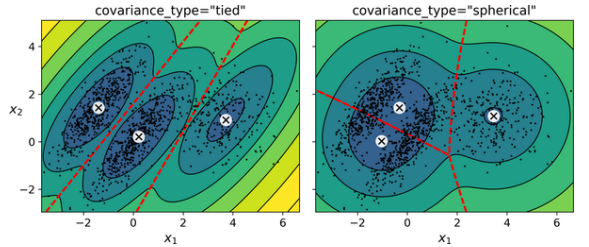

The algorithm has a complexity of $O(kmn)$ if data has a clustering structure and `covariance_type` is set to either `"spherical"` or `"diag"`, while it has a complexity of $O(kmn^2 + kn^3)$ is it set to `"tied"` or `"full"`.

#### Finding Optimal Number of Clusters
Just as k-means, Gaussian Mixtures requires to specify a number of cluster, but here we can't use inertia or silhouette score, cause they are not reliable with different sizes clusters. What we can do is instead find the model minimizing a **Theoretical Information Criterio**, such as **Bayesian Information Criterion (BIC)** or **Akaike Information Criterion (AIC)**:

$$ BIC = \log(m)p - 2 \log(\hat L)$$
$$ AIC = 2p - 2 \log(\hat L)$$

where:
- $m$: number of instances;
- $p$: number of parameters learned by the model;
- $\hat L$: **Maximum Likelihood Function** of the model.

Both BIC and AIC penalize models with more parameter to learn (e.g., more clusters) and reward models fitting data well; they usually select the same model, but sometimes BIC tends to be simpler then AIC, not fitting data well (especially with large datasets).

Let's go more in depth in the Likelihood Function and how "likelihood" differs from "probability": given a statistical model with some parameter $\theta$ we have:
- **Probability**: how plausible a future outcome $x$ is knowing $\theta$;
- **Likelihood**: how plausible a particular set of parameter values $\theta$ is, after outcome $x$ is known.

Let's consider a 1D mixture model of 2 Gaussian distribution centered at -4 and +1 (for simplicity the model has 1 parameter $\theta$ controlling the Standard Deviations of both distributions).

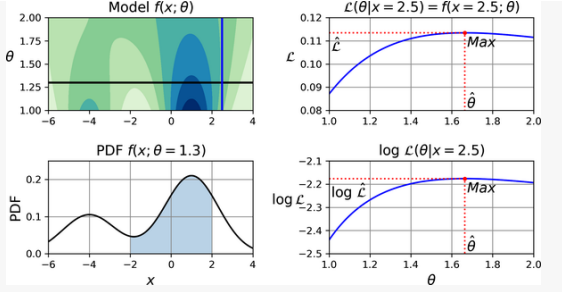

In top-left plot, the entire model $f(x; \theta)$ is a function of both $x$ and $\theta$; to estimate the prob distribution of a future outcome $x$ we need to set $\theta$, if we set it to, for example, 1.3 (horizontal line), we get the probability density function $f(x; \theta = 1.3)$, which is the lower-left plot. If we want to estimate the probability that $x$ falls between -2 and +2, we must compute the integral of PDF in this range.

If instead we don't know $\theta$ but we observed an instance $x = 2.5$, represented by the vertical line in the upper-left plot, we would get the likelihood function $L(\theta | x = 2.5) = f(x = 2.5; \theta)$, represented in the upper-right plot.

(in short, PDF is a function of $x$ with $\theta$ fixed, while likelihood is a function of $\theta$ with $x$ fixed)

Given a dataset $X$, a common task could be to estimate the most likely values for the model parameters, i.e., the values maximzing the likelihood function given $X$. In this example, given $x = 2,5$, the **Maximum Likelihood Estimate (MLE)** of $\theta$ is $\hat \theta \approx 1.66$. If a prior probability distribution $g$ over $\theta$ exists, it is possible to take it into account by maximizing $L(\theta | x)g(\theta)$ rather than just maximizing $L(\theta | x)$: this is called **Maximum A-Posteriori (MAP)** estimation. Since MAP contrains the parameter values, it is like a regularized version of MLE.

Notice how maximizing the Likelihood function is equivalent to maximizing its logarithm (lower-right plot), which turns out to be generally easier to maximize. If for example you observed some independent instances $x^{(1)}$ to $x^{(m)}$, you would need to find the value of $\theta$ maximizing the product of individual likelihood functions, but it's equivalent, and easier, to maximize the sum of the log of the individual likelihood functions, thanks to the magic of logarithm in converting products into sums:

$$\log (ab) = \log (a) + \log(b)$$

Once you estimated $\hat \theta$ maximizing the likelihood function, you can compute $\hat L = L(\hat \theta, X)$, so that you can compute AIC and BIC.

We can get BIC and AIC with the `bic()` and `aic()` methods:

In [83]:
gm.bic(X), gm.aic(X)

(np.float64(2808.2855871998922), np.float64(2724.853747457196))

You can plot various clusters AIC and BIC and choose the minimum one:

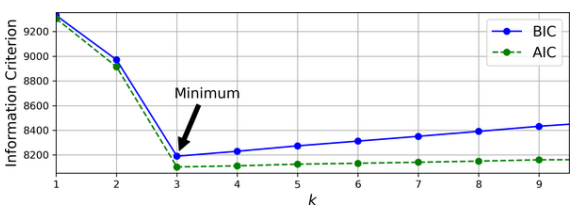

#### Bayesian Gaussian Mixture Models
Instead of searching for the optimal number of clusters, you can use the `BayesianGaussianMixture` class, which gives weights equal (or close) to zero to unnecessary clusters. Set `n_components` to a value that you have good reason to believe is greater than the optimal number of clusters (this require some minimal knowledge about the problem) and the model will eliminate unnecessary clusters automatically:

In [84]:
from sklearn.mixture import BayesianGaussianMixture

bgm = BayesianGaussianMixture(n_components=10, n_init=10, random_state=42)
bgm.fit(X)
bgm.weights_.round(2)

/home/essskevin/projects/hands_on_ml/venv/lib/python3.12/site-packages/sklearn/mixture/_base.py:275: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


array([0.07, 0.15, 0.13, 0.12, 0.14, 0.16, 0.  , 0.11, 0.11, 0.  ])

Algorithm automatically detects 8 clusters are needed.

## 3. Clustering Use Cases

### Clustering for Image Segmentation
**Image Segmentation** is the task of partitioning an image into multiple segments. It also splits into multiple variants:
- **Color Segmentation**: assigning pixels with similar colors to same segment;
- **Semantic Segmentation**: assigning pixels of the same object type to same segment;
- **Instance Segmentation**: assigning pixels of the same individual object to the same segment.

Nowadays, the state of the art in Semantic and Instance segmentation is achieved using **Convolutional Neural Networks (CNNs)** (Chapter 14) or **Vision Transformers** (Chapter 16).

We will focus on a k-means-based Color Segmentation task: let's start by loading the `ladybug.png` image using the `PIL` (Python Imaging Library) package:

In [15]:
import PIL
image = np.asarray(PIL.Image.open('../images/ladybug.png'))
image.shape

(533, 800, 3)

The image is represented as a 3D array: (height, width, color channels). Basically for each pixel we got a 3D vector containing intensities of red, green and blue from 0 to 255.

We will:
- reshape the array to get a long list of RGB colors;
- use k-means to cluster these colors in 8 clusters: this gives an array containing the nearest cluster center for each pixel (which is the mean color of each pixel's cluster);
- reshape the array to the original image shape.

In [16]:
X = image.reshape(-1, 3)
kmeans = KMeans(n_clusters=8, random_state=42).fit(X)
segmented_img = kmeans.cluster_centers_[kmeans.labels_]
segmented_img = segmented_img.reshape(image.shape)

Let's now compare the 2 images:

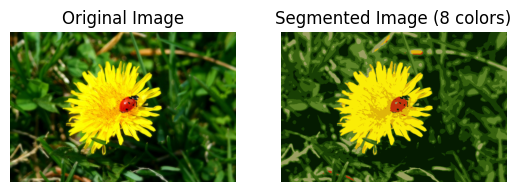

In [17]:
plt.subplot(1, 2, 1)
plt.title('Original Image')
plt.imshow(image)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title('Segmented Image (8 colors)')
plt.imshow(segmented_img.astype(np.uint8))
plt.axis('off')

plt.show()

Below an example of what we would obtain with different number of clusters:

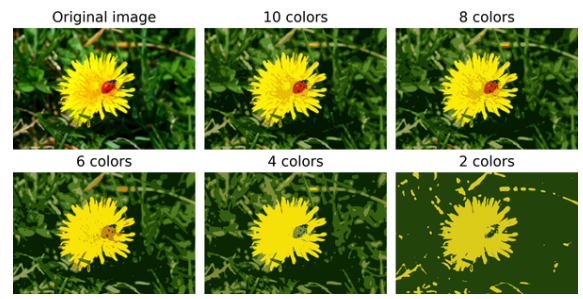

### Clustering for Semi-Supervised Learning
As we already stated, **Semi-Supervised Learning** tasks involve having plenty of unlabeled instances and few labeled ones.

Let's load the digits dataset, which is a MNIST-like dataset with 1797 grayscale 8x8 images with digits from 0 to 9:

In [18]:
from sklearn.datasets import load_digits

X, y = load_digits(return_X_y=True)
X_train, y_train = X[:1400], y[:1400]
X_test, y_test = X[1400:], y[1400:]

We will pretend to have labels for 50 instances. Let's start by building a baseline logistic regression model using these 50 labeled instances (of course the test set will be considered to be labeled to evaluate the performance):

In [19]:
from sklearn.linear_model import LogisticRegression

n_labeled = 50
log_reg = LogisticRegression(max_iter=10000, random_state=42)
log_reg.fit(X_train[:n_labeled], y_train[:n_labeled])
log_reg.score(X_test, y_test)

0.7581863979848866

Only around 75.8% accuracy (training on full training set should yield about 90% accuracy).

Let's now use clustering to improve the performance: we'll cluster into 50 clusters, then for each cluster we'll find the image closest to the centroid, which we will call the **Representative Image**:

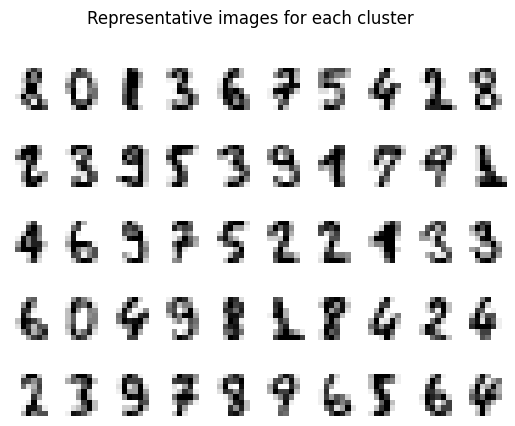

In [20]:
k = 50
kmeans = KMeans(n_clusters=k, random_state=42)
X_digits_dist = kmeans.fit_transform(X_train)
representative_digit_idx = np.argmin(X_digits_dist, axis=0)
X_representative_digits = X_train[representative_digit_idx]

for digit_idx in representative_digit_idx:
    plt.subplot(5, 10, list(representative_digit_idx).index(digit_idx) + 1)
    plt.imshow(X_train[digit_idx].reshape(8, 8), cmap = 'binary')
    plt.axis('off')
    
plt.suptitle('Representative images for each cluster')
plt.show()

We'll now need to manually label each image:

In [21]:
y_representative_digits = np.array([8, 0, 1, 3, 6, 7, 5, 4, 2, 8, 
                                    2, 3, 9, 5, 3, 9, 1, 7, 9, 1, 
                                    4, 6, 9, 7, 5, 2, 2, 1, 3, 3, 
                                    6, 0, 4, 9, 8, 1, 8, 4, 2, 4, 
                                    2, 3, 9, 7, 8, 9, 6, 5, 6, 4])

We have 50 labeled instances as before, but these are now representative images of their clusters. Let's check if performance increases:

In [22]:
log_reg = LogisticRegression(max_iter=10000, random_state=42)
log_reg.fit(X_representative_digits, y_representative_digits)
log_reg.score(X_test, y_test)

0.8337531486146096

We went from 75.8% to 83.3% accuracy!

What if then apply **Label Propagation** (i.e., propagate the labels to all the other instances in the same cluster)? 

In [23]:
y_train_propagated = np.empty(len(X_train), dtype=np.int64)
for i in range(k):
    y_train_propagated[kmeans.labels_ == i] = y_representative_digits[i]
    
log_reg = LogisticRegression(max_iter=10000, random_state=42)
log_reg.fit(X_train, y_train_propagated)
log_reg.score(X_test, y_test)

0.8690176322418136

We went from 83.3% to 86.9% accuracy!

This is due to the fact that our propagated labels are actually pretty good. Let's check their accuracy:

In [24]:
(y_train_propagated == y_train).mean()

np.float64(0.9542857142857143)

(Another possibility could be to drop the instances that are farthest from their cluster centers, which are most likely outliers and may be wrongly labelled; this could improve performance even further, but this was not the case)

We can implement the above with Scikit-Learn using `semi_supervised.LabelSpreading` and `semi_supervised.LabelPropagation`.

Another different approach is to use `semi_supervised.SelfTrainingClassifier`, which takes a base classifier (e.g., `RandomForestClassifier`), trains it on the labeled instances, predict the labels for the unlabeled samples, then updates the training set with the labels it is most confidend about and repeats the process until it cannot add any labels.

Another completely different approach is **Active Learning**, which involves a human expert to interacts with the algorithm providing labels. A special type of this is **Uncertainty Sampling**, in which the model is trained on the labeled data and makes predictions; then, the instances for which the model is most uncertain (i.e., lowest estimated probability) are given to the expert for labeling and the model re-trains, until the performance improvement is not worth the labeling effort.

### Anomaly detection
**Anomaly Detection** can be performed with Gaussian mixture model: any instance located in a low-density region is considered an anomaly. To do so, density threshold must be set: suppose we know the ratio of anomalies is 2%, we should put the density threshold to the value resulting in having 2% of instances located in areas below that threshold density.

If this ends with too much False Positive (i.e., no anomalies flagged as anomalies), you can lower the threshold; if this ends with too much False Negatives (i.e., anomalies flagged as no anomalies), you can increase it (this is the **Precision/Recall Trade-Off** (Chapter 3)).

Let's use the initial Gaussian Mixture model on the previous dataset:

In [82]:
X, y = make_moons(n_samples = 1000, noise = 0.05, random_state = 42)

densities = gm.score_samples(X)
density_threshold = np.percentile(densities, 2)
anomalies = X[densities < density_threshold]

A closely related task is **Novelty Detection**, which differs from Anomaly Detection simply in the fact that the dataset is assumed to be "clean", without outliers.

#### Other Algorithms for Anomaly and Novelty Detection
- `EllipticEnvelope` implements the **Fast-MCD (Minimum Covariance Determinant)** which assumes that normal instances (inlier) are generated from a single Gaussian distribution (not a mixture), while there are anomalies (outliers) not generated from that. The model estimates the parameters of the Gaussian distribution ignoring instances that are most likely outliers;
- **Isolation Forest** is a random forest in which each decision tree grows randomly (at each node, it picks a random threshold value (between min and max) to split the dataset in 2); the dataset gradually gets chopped into pieces until each instance is isolated from the others. Anomalies are usually far from other instances (i.e., they get isolated in fewer steps); works great with high-dimensional datasets;
- **Local Outlier Factor (LOF)** compares density of instances around a given instance to the density around its neigbors: anomalies are often more isolated than its $k$-nearest neighbors;
- **One-Class SVM** (better for Novelty Detection): a SVM which tries to separate instances in high-dimensional space from the origin; this corresponds to find a small region ecompassing all the instances in the original space: if an instance doesn't fall within this region, it is an anomaly. You can tweak the usual SVM parameters plus a margin hyperparameter corresponding to the probability of a new instance to be considered novel when it is normal. Works great with high-dimensional datasets, but doesn't scale well with large datasets;
- **PCA and other Dimensionality Reduction Techniques with an** `inverse_transform()` **method**: the reconstuction error of an anomaly instance is usually greater than the one of a normal one.